In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
customer_churn = pd.read_csv(
    "../data/processed/customer_churn.csv"
)

print("Shape:", customer_churn.shape)
print("\nColumns:")
print(customer_churn.columns.tolist())

Shape: (96096, 48)

Columns:
['customer_unique_id', 'total_orders', 'total_items', 'total_spent', 'total_freight', 'unique_products', 'unique_sellers', 'avg_order_value', 'last_purchase_date', 'recency_days', 'first_purchase_date', 'customer_lifetime_days', 'active_months', 'avg_review_score', 'total_reviews', 'has_review', 'total_payment', 'avg_payment_value', 'total_payment_records', 'max_installments', 'credit_card_payments', 'boleto_payments', 'voucher_payments', 'debit_card_payments', 'avg_delivery_days', 'max_delivery_days', 'avg_delivery_delay', 'late_orders', 'on_time_orders', 'purchase_frequency', 'spend_per_item', 'orders_per_seller', 'products_per_order', 'freight_cost_ratio', 'payment_to_spent_ratio', 'seller_diversity', 'spend_per_order', 'R_score', 'F_score', 'M_score', 'RFM_score', 'customer_segment', 'spend_score', 'frequency_score', 'customer_value_score', 'cluster', 'kmeans_segment', 'churn']


In [3]:
# Target
y = customer_churn["churn"]

# Numerical features used for explanation
feature_columns = [
    "total_orders",
    "total_items",
    "total_spent",
    "total_freight",
    "unique_products",
    "unique_sellers",
    "avg_order_value",
    "recency_days",
    "customer_lifetime_days",
    "active_months",
    "avg_review_score",
    "total_reviews",
    "has_review",
    "total_payment",
    "avg_payment_value",
    "total_payment_records",
    "max_installments",
    "credit_card_payments",
    "boleto_payments",
    "voucher_payments",
    "debit_card_payments",
    "avg_delivery_days",
    "max_delivery_days",
    "avg_delivery_delay",
    "late_orders",
    "on_time_orders",
    "purchase_frequency",
    "spend_per_item",
    "orders_per_seller",
    "products_per_order",
    "freight_cost_ratio",
    "payment_to_spent_ratio",
    "seller_diversity",
    "spend_per_order"
]

X = customer_churn[feature_columns]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nNumber of features:", len(feature_columns))
print("\nMissing values:", X.isnull().sum().sum())

X shape: (96096, 34)
y shape: (96096,)

Number of features: 34

Missing values: 8940


In [4]:
# Handle Missing Values
missing_values = X.isnull().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

print("Features with missing values:")
print(missing_values)

Features with missing values:
max_delivery_days     2740
avg_delivery_days     2740
avg_delivery_delay    2740
avg_review_score       716
max_installments         3
avg_payment_value        1
dtype: int64


In [5]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy = "median")

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns = X.columns,
    index = X.index
)
print("Original missing values:", X.isnull().sum().sum())
print("Missing values after imputation:", X_imputed.isnull().sum().sum())
print("X_imputed shape:", X_imputed.shape)

Original missing values: 8940
Missing values after imputation: 0
X_imputed shape: (96096, 34)


In [6]:
# Train the Churn Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train,y_test = train_test_split(

    X_imputed,
    y,
    test_size = 0.2,
    random_state=42,
    stratify = y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

churn_model = LogisticRegression(
    max_iter = 1000,
    class_weight = "balanced",
    random_state = 42

)

churn_model.fit(X_train, y_train)

y_pred = churn_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))












Training data: (76876, 34)
Testing data: (19220, 34)

Accuracy: 0.9781997918834547

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     13547
           1       0.94      0.99      0.96      5673

    accuracy                           0.98     19220
   macro avg       0.97      0.98      0.97     19220
weighted avg       0.98      0.98      0.98     19220



c:\Users\sanju\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
%pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [9]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [10]:
# Create the SHAP Explainer

explainer = shap.LinearExplainer(
    churn_model,
    X_train

)
print("SHAP explainer created successfully.")

Background dataset has 76876 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=76876 when initializing the masker.


SHAP explainer created successfully.


In [11]:
X_shap = X_test.iloc[:1000]

shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated successfully.")
print("SHAP values shape:", shap_values.shape)

SHAP values calculated successfully.
SHAP values shape: (1000, 34)


In [12]:
# Global Feature Importance

shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

print(shap_importance.head(15))



                 feature  mean_abs_shap
0           recency_days      11.523320
1      avg_delivery_days       8.936598
2      max_delivery_days       8.610263
3      avg_payment_value       4.309272
4            total_spent       1.663029
5        avg_order_value       1.220094
6        spend_per_order       1.220094
7        boleto_payments       0.477542
8       avg_review_score       0.427845
9       max_installments       0.373586
10  credit_card_payments       0.286937
11    products_per_order       0.282407
12         total_payment       0.231119
13      seller_diversity       0.228548
14          total_orders       0.221249


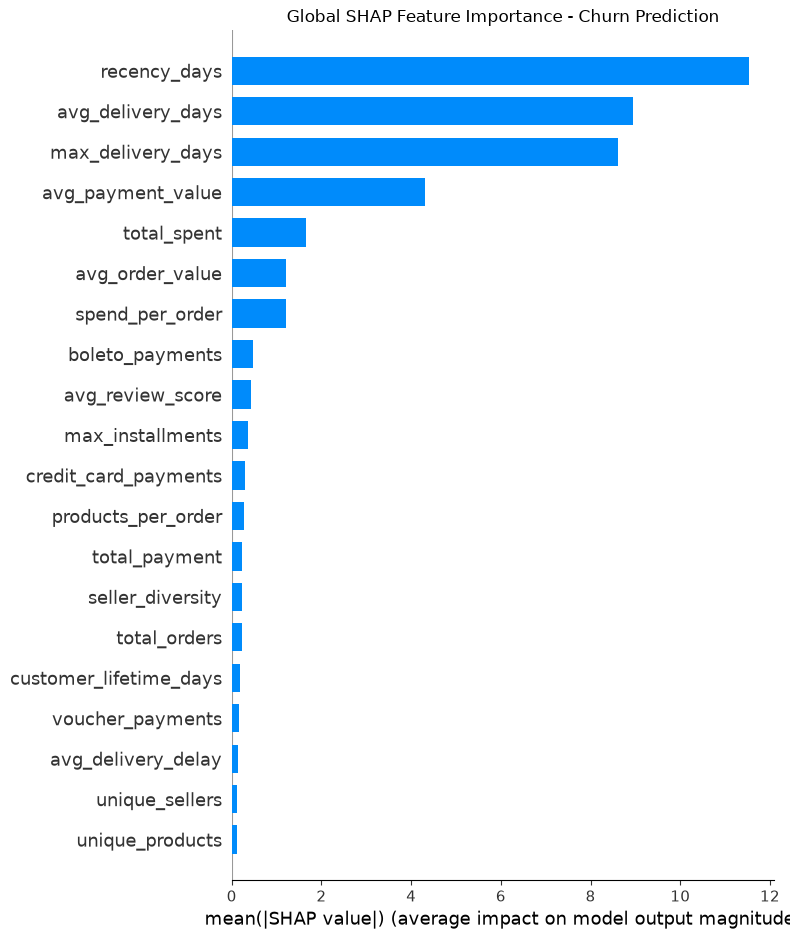

In [13]:
# Create Global SHAP Plot

plt.figure(figsize = (10,7))
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type = "bar",
    show = False
  
 )

plt.title("Global SHAP Feature Importance - Churn Prediction")
plt.tight_layout()
plt.show()

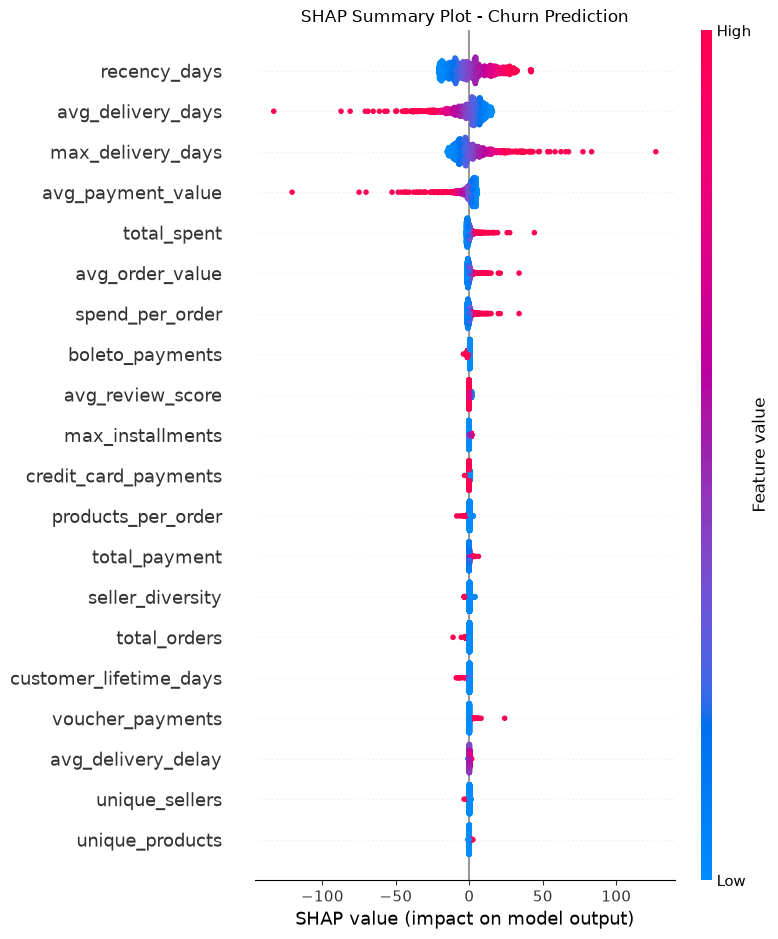

In [14]:
# SHAP Beeswarm Plot

plt.figure(figsize = (10,8))

shap.summary_plot(
    shap_values,
    X_shap,
    show = False
)

plt.title("SHAP Summary Plot - Churn Prediction")
plt.tight_layout()
plt.show()

In [15]:
customer_index = 0

customer_data = X_shap.iloc[[customer_index]]

customer_shap_values = shap_values[customer_index]

print("Customer index:", customer_index)
print("Actual churn:", y_test.iloc[customer_index])

print("\nTop factors influencing this prediction:")

individual_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "shap_value": customer_shap_values
})

individual_importance["abs_shap"] = np.abs(
    individual_importance["shap_value"]
)

individual_importance = individual_importance.sort_values(
    "abs_shap",
    ascending=False
).head(10)

print(individual_importance)

Customer index: 0
Actual churn: 0

Top factors influencing this prediction:
                 feature  shap_value  abs_shap
7           recency_days   -6.140943  6.140943
21     avg_delivery_days    2.668833  2.668833
22     max_delivery_days   -2.496091  2.496091
10      avg_review_score    0.561915  0.561915
16      max_installments    0.512216  0.512216
18       boleto_payments    0.304038  0.304038
14     avg_payment_value   -0.264327  0.264327
29    products_per_order    0.167744  0.167744
17  credit_card_payments   -0.154267  0.154267
32      seller_diversity    0.138388  0.138388


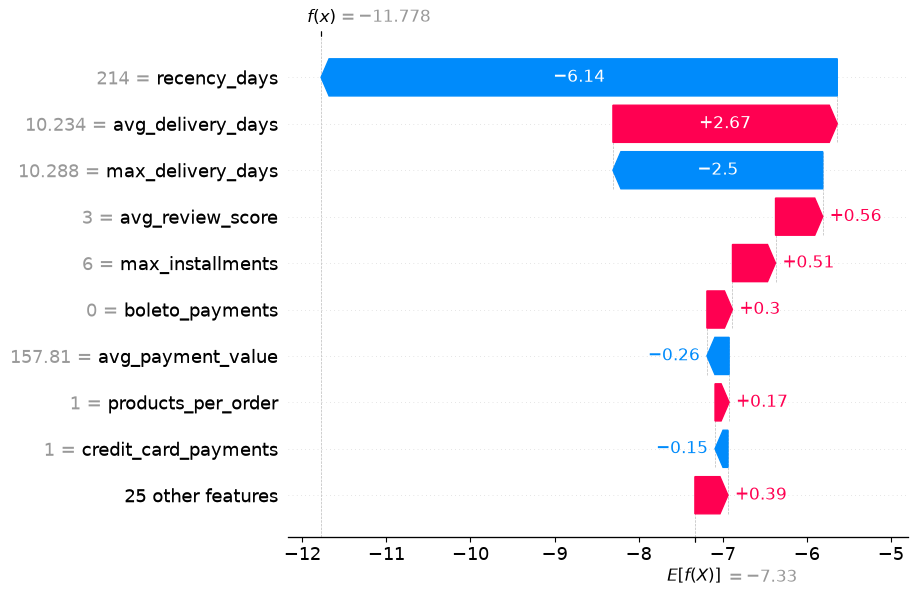

In [16]:
# Individual SHAP Waterfall Plot
customer_explanation = shap.Explanation(
    values=customer_shap_values,
    base_values=explainer.expected_value,
    data=customer_data.iloc[0].values,
    feature_names=X_shap.columns
)

shap.plots.waterfall(
    customer_explanation,
    max_display=10
)


In [17]:
# Calculate Churn Probability
customer_probability = churn_model.predict_proba(
    customer_data
)[0, 1]

print(f"Predicted churn probability: {customer_probability:.4f}")
print(f"Predicted churn probability: {customer_probability * 100:.2f}%")

Predicted churn probability: 0.0000
Predicted churn probability: 0.00%


In [18]:
print(f"{customer_probability:.4f}")

0.0000


In [19]:
customer_probability = churn_model.predict_proba(
    customer_data
)[0, 1]

print("Predicted churn probability:", customer_probability)
print(f"Predicted churn probability: {customer_probability * 100:.6f}%")

Predicted churn probability: 7.675093621603239e-06
Predicted churn probability: 0.000768%


In [20]:
# Create a Customer Explainability Summary
predicted_churn = churn_model.predict(customer_data)[0]

print("Customer Explainability Summary")
print("--------------------------------")
print("Customer index:", customer_index)
print("Actual churn:", y_test.iloc[customer_index])
print("Predicted churn:", predicted_churn)
print(f"Churn probability: {customer_probability * 100:.6f}%")

print("\nTop 5 influencing features:")

print(
    individual_importance[
        ["feature", "shap_value"]
    ].head(5).to_string(index=False)
)

Customer Explainability Summary
--------------------------------
Customer index: 0
Actual churn: 0
Predicted churn: 0
Churn probability: 0.000768%

Top 5 influencing features:
          feature  shap_value
     recency_days   -6.140943
avg_delivery_days    2.668833
max_delivery_days   -2.496091
 avg_review_score    0.561915
 max_installments    0.512216


In [21]:
#Save SHAP Feature Importance
shap_importance.to_csv(
    "../data/processed/shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved successfully.")
print("Shape:", shap_importance.shape)

SHAP feature importance saved successfully.
Shape: (34, 2)


In [22]:
# Save Individual SHAP Explanations

individual_shap = pd.DataFrame(
    shap_values,
    columns=X_shap.columns,
    index=X_shap.index
)

# Add customer information
individual_shap.insert(
    0,
    "customer_unique_id",
    customer_churn.loc[
        X_shap.index,
        "customer_unique_id"
    ].values
)

# Add actual and predicted churn information
individual_shap["actual_churn"] = y_test.loc[
    X_shap.index
].values

individual_shap["predicted_churn"] = churn_model.predict(
    X_shap
)

individual_shap["churn_probability"] = churn_model.predict_proba(
    X_shap
)[:, 1]

# Save
individual_shap.to_csv(
    "../data/processed/individual_shap_explanations.csv",
    index=False
)

print("Individual SHAP explanations saved successfully.")
print("Shape:", individual_shap.shape)
print("\nColumns:", individual_shap.columns.tolist())

Individual SHAP explanations saved successfully.
Shape: (1000, 38)

Columns: ['customer_unique_id', 'total_orders', 'total_items', 'total_spent', 'total_freight', 'unique_products', 'unique_sellers', 'avg_order_value', 'recency_days', 'customer_lifetime_days', 'active_months', 'avg_review_score', 'total_reviews', 'has_review', 'total_payment', 'avg_payment_value', 'total_payment_records', 'max_installments', 'credit_card_payments', 'boleto_payments', 'voucher_payments', 'debit_card_payments', 'avg_delivery_days', 'max_delivery_days', 'avg_delivery_delay', 'late_orders', 'on_time_orders', 'purchase_frequency', 'spend_per_item', 'orders_per_seller', 'products_per_order', 'freight_cost_ratio', 'payment_to_spent_ratio', 'seller_diversity', 'spend_per_order', 'actual_churn', 'predicted_churn', 'churn_probability']


In [23]:
# Validate the Saved SHAP Data

print("Missing values:", individual_shap.isnull().sum().sum())

print(
    "\nPredicted churn distribution:"
)
print(
    individual_shap["predicted_churn"].value_counts()
)

print(
    "\nChurn probability range:"
)
print(
    "Minimum:",
    individual_shap["churn_probability"].min()
)

print(
    "Maximum:",
    individual_shap["churn_probability"].max()
)

print(
    "\nSHAP explanation shape:",
    individual_shap.shape
)

Missing values: 0

Predicted churn distribution:
predicted_churn
0    706
1    294
Name: count, dtype: int64

Churn probability range:
Minimum: 4.023883768184189e-17
Maximum: 1.0

SHAP explanation shape: (1000, 38)


In [24]:
# Create customer-level SHAP summary
# Step 21: Create a customer-level SHAP summary

shap_summary = individual_shap[
    [
        "customer_unique_id",
        "actual_churn",
        "predicted_churn",
        "churn_probability"
    ]
].copy()

# Add the top SHAP features for each customer
top_shap_features = []

for i in range(len(X_shap)):
    customer_values = shap_values[i]

    feature_contributions = pd.Series(
        customer_values,
        index=X_shap.columns
    )

    top_features = (
        feature_contributions
        .abs()
        .sort_values(ascending=False)
        .head(5)
        .index
        .tolist()
    )

    top_shap_features.append(", ".join(top_features))

shap_summary["top_5_shap_features"] = top_shap_features

# Save the summary
shap_summary.to_csv(
    "customer_shap_summary.csv",
    index=False
)

print("Customer SHAP summary created successfully.")
print("Shape:", shap_summary.shape)
print("\nFirst 5 rows:")
display(shap_summary.head())

Customer SHAP summary created successfully.
Shape: (1000, 5)

First 5 rows:


,customer_unique_id,actual_churn,predicted_churn,churn_probability,top_5_shap_features
10421,1b93bce517b6d17c42f20da04f077bf5,0,0,7.675094e-06,"recency_days, avg_delivery_days, max_delivery_..."
81246,d831920740803fe95943cf7c9f243ee6,1,1,9.854855e-01,"recency_days, avg_delivery_days, max_delivery_..."
71651,be958376bd32586c2cf944873e565aa4,0,0,8.052309e-08,"recency_days, avg_delivery_days, max_delivery_..."
4697,0c6222b2461f93cae8121213eb330bae,0,0,6.317423e-06,"avg_delivery_days, max_delivery_days, recency_..."
52881,8d101c47a4c3fb0d038d454668b1464c,1,1,1.000000e+00,"recency_days, avg_delivery_days, max_delivery_..."


In [25]:
# Step 22: Final validation of Explainable ML

print("===== EXPLAINABLE ML FINAL VALIDATION =====")

print("\n1. SHAP Feature Importance:")
print("Shape:", shap_importance.shape)

print("\n2. Individual SHAP Explanations:")
print("Shape:", individual_shap.shape)

print("\n3. Customer SHAP Summary:")
print("Shape:", shap_summary.shape)

print("\n4. Missing Values:")
print("SHAP Importance:", shap_importance.isnull().sum().sum())
print("Individual Explanations:", individual_shap.isnull().sum().sum())
print("Customer Summary:", shap_summary.isnull().sum().sum())

print("\n5. Output Files:")
print("shap_feature_importance.csv")
print("individual_shap_explanations.csv")
print("customer_shap_summary.csv")

print("\n===== PART 11 COMPLETE =====")

===== EXPLAINABLE ML FINAL VALIDATION =====

1. SHAP Feature Importance:
Shape: (34, 2)

2. Individual SHAP Explanations:
Shape: (1000, 38)

3. Customer SHAP Summary:
Shape: (1000, 5)

4. Missing Values:
SHAP Importance: 0
Individual Explanations: 0
Customer Summary: 0

5. Output Files:
shap_feature_importance.csv
individual_shap_explanations.csv
customer_shap_summary.csv

===== PART 11 COMPLETE =====
